## Set Up

In [1]:
#%pip install pandas
#%pip install numpy
#%pip install matplotlib
#%pip install seaborn
#%pip install scipy
#%pip install scikit-posthocs

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp

## Preparing Data

### Reading Data

In [3]:
# Reading in Data
df = pd.read_csv(Path.cwd() / "Data" / "Raw" / "insurance_dataset.csv",
                 dtype={"is_capped_incurred":"Int64",
                        "bi_count":"Int64",
                        "ad_count":"Int64",
                        "pd_count":"Int64",
                        "th_count":"Int64",
                        "ws_count":"Int64",
                        "vehicle_age":"Int64"})

# Converting dates and times
df["start_date"] = pd.to_datetime(df["start_date"], format = "%d/%m/%Y")

#first removing values from 1753
df["vehicle_purchase_date"] = (
    df["vehicle_purchase_date"]
        .where(~df["vehicle_purchase_date"].str.contains("1753", na = False))
)                                     
df["vehicle_purchase_date"] = pd.to_datetime(df["vehicle_purchase_date"], format = "%d/%m/%Y")

df["licence_test_date"] = pd.to_datetime(df["licence_test_date"], format = "%d/%m/%Y")

### Profiling Missing Data 1

In [4]:
# Profiling missing values
missing_values_before = (
    pd.DataFrame(df.isna()
                 .sum())
    .reset_index()
    .rename(columns={"index":"Column",
                     0:"Values Missing"})
    .sort_values("Values Missing", ascending=False)
)

# Exporting Missing Values Report
#missing_values_before.to_csv(Path.cwd() / "Reports" / "missing_values_before.csv", index=False)

### Difficult Data Quality Issues

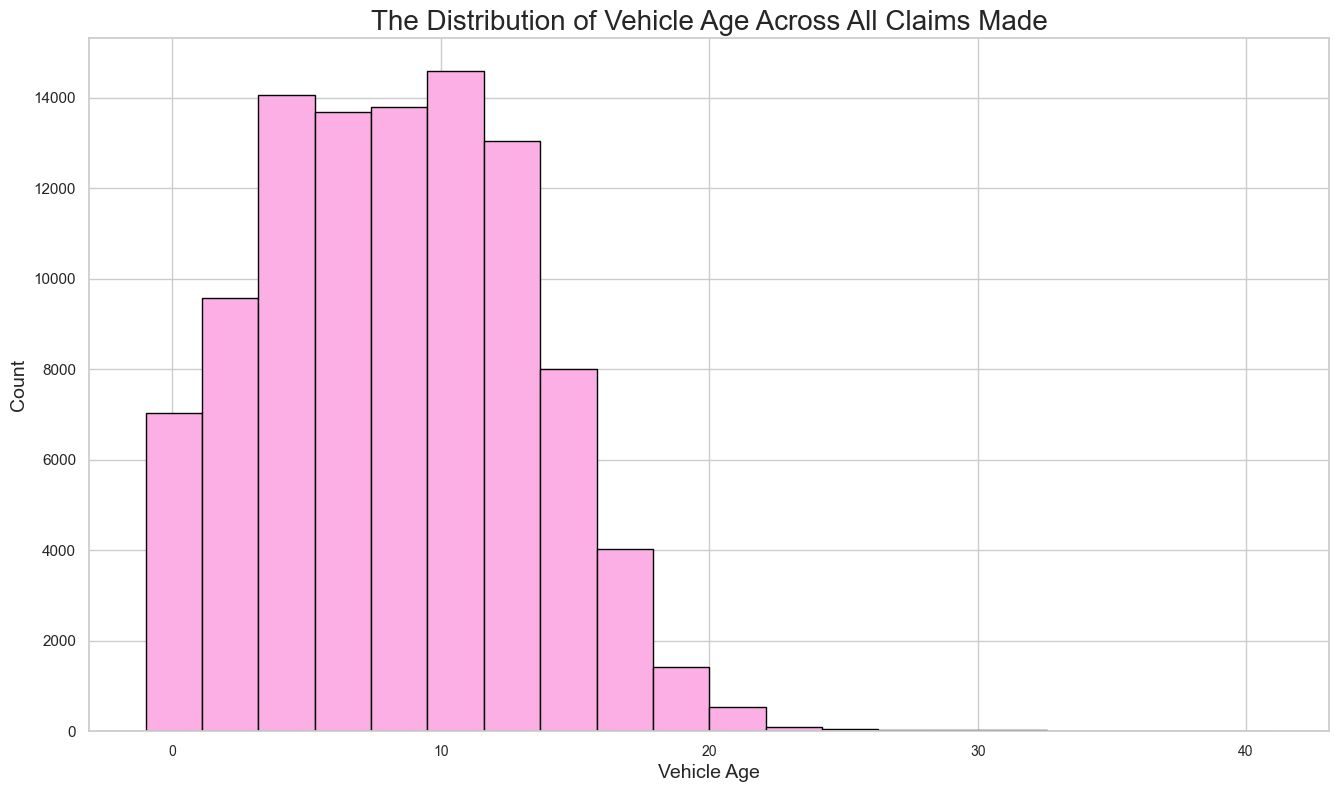

In [5]:
fig = plt.figure(figsize = (16,9))

sns.set_theme(style = "whitegrid")

plt.hist(df["vehicle_age"],
        edgecolor = "black",
        bins = 20,
        color = sns.color_palette("colorblind")[6])

plt.xlabel("Vehicle Age", fontsize = 14)
plt.ylabel("Count", fontsize = 14)
plt.title("The Distribution of Vehicle Age Across All Claims Made", fontsize = 20)
plt.xticks(fontsize = 10)

plt.show()

sns.set_theme(style = "whitegrid")

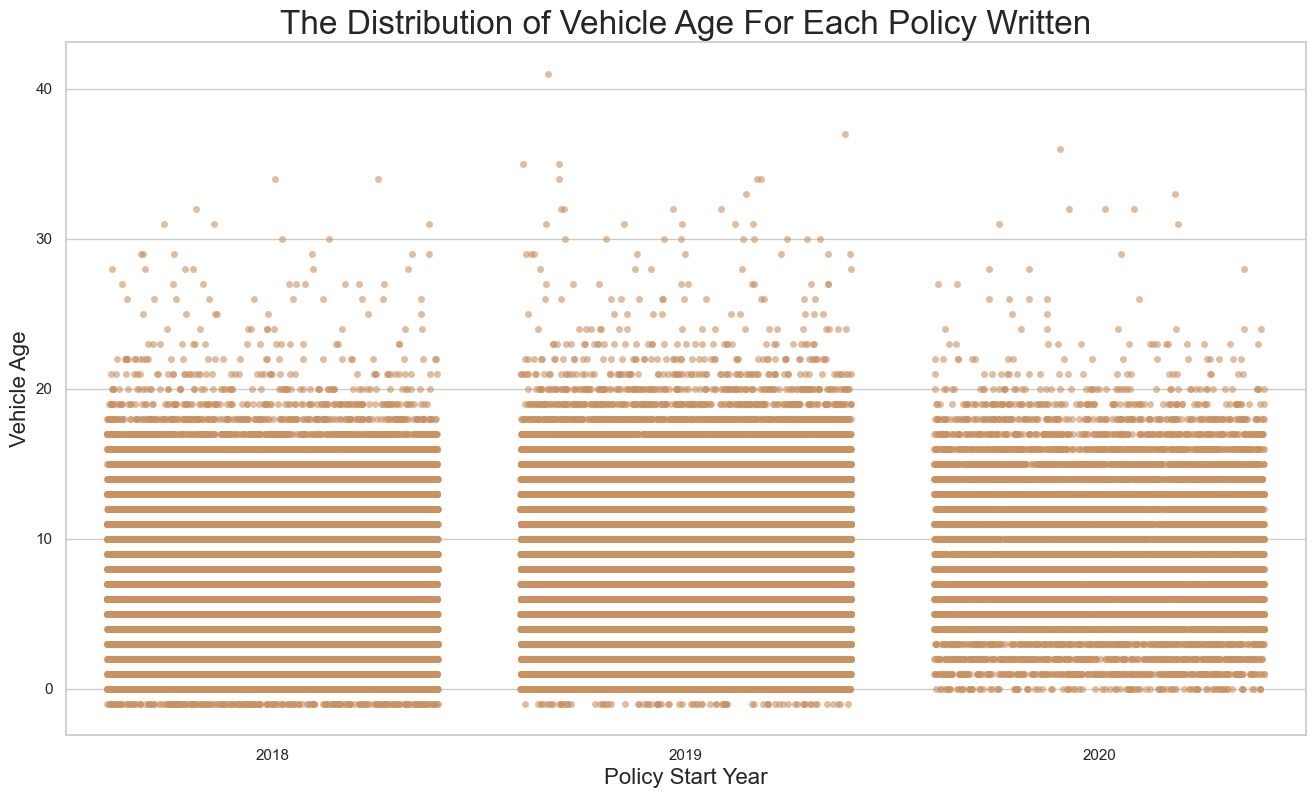

In [6]:
# Creating a Year column for aggregation
df["start_year"] = df["start_date"].dt.year.astype("category")
df["start_year"] = df["start_year"].cat.reorder_categories([2018, 2019, 2020])

fig = plt.figure(figsize = (16, 9))

sns.set_theme(style = "whitegrid")

sns.stripplot(data = df,
              x = "start_year",
              y = "vehicle_age",
             jitter = 0.4,
              alpha = 0.6,
             color = sns.color_palette("colorblind")[5])

plt.xlabel("Policy Start Year", fontsize = 16),
plt.ylabel("Vehicle Age", fontsize = 16)
plt.title("The Distribution of Vehicle Age For Each Policy Written", fontsize = 24)

plt.show()

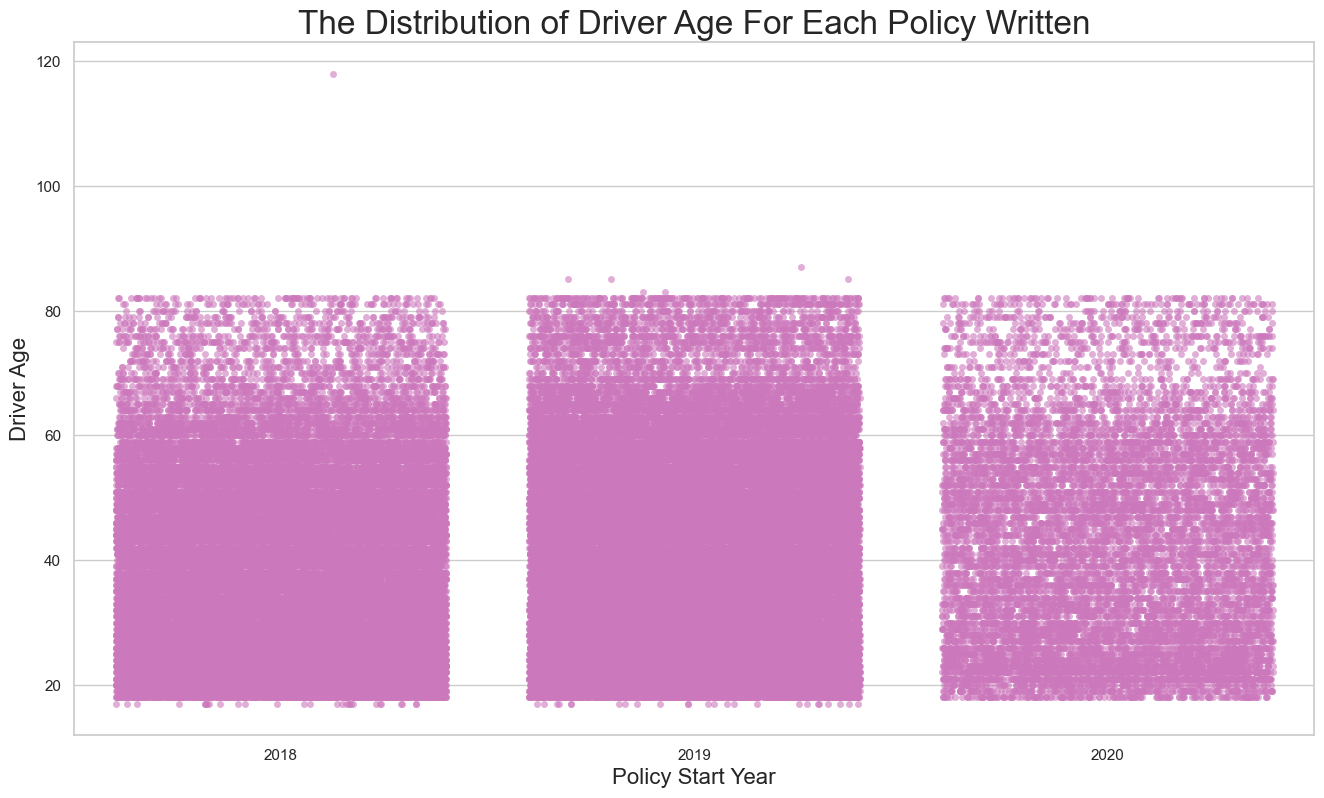

In [7]:
fig = plt.figure(figsize = (16, 9))

sns.set_theme(style = "whitegrid")

sns.stripplot(data = df,
              x = "start_year",
              y = "d1_age",
             jitter = 0.4,
              alpha = 0.6,
             color = sns.color_palette("colorblind")[4])

plt.xlabel("Policy Start Year", fontsize = 16),
plt.ylabel("Driver Age", fontsize = 16)
plt.title("The Distribution of Driver Age For Each Policy Written", fontsize = 24)

plt.show()

In [8]:
neg_incurred = (
    (df.loc[:, list(df.columns[df.columns.str.endswith("incurred")][1:])] < 0)
        .sum()
        .reset_index()
        .rename(columns = {"index":"Column", 0:"Total Negative Values"})
        .sort_values("Total Negative Values", ascending = False)
)

neg_incurred
#neg_incurred.to_csv(Path.cwd() / "Reports" / "negative_incurred.csv", index = False)

,Column,Total Negative Values
3,ad_incurred,1715
0,incurred,1073
1,capped_incurred,1073
4,pd_incurred,6
5,th_incurred,1
2,bi_incurred,0
6,ws_incurred,0


### Replacing Values

In [9]:
## Replacing Values

#Cleaning up the name of business providers
df["business_provider"] = df["business_provider"].str.replace({" ":"",
                                                               "+":"and",
                                                               "DefaultDefault":"Default",
                                                               "DefaultCampaign":"Default"})


#Replacing age 118 with NaN
df["d1_age"] = df["d1_age"].where(df["d1_age"] != 118)

df["d1_residency_years"] = df["d1_residency_years"].where(df["d1_residency_years"] != 118)

#Replacing NA with 0
df["incurred"] = df["incurred"].fillna(0)
df["capped_incurred"] = df["capped_incurred"].fillna(0)
df["bi_incurred"] = df["bi_incurred"].fillna(0)
df["ad_incurred"] = df["ad_incurred"].fillna(0)
df["pd_incurred"] = df["pd_incurred"].fillna(0)
df["th_incurred"] = df["th_incurred"].fillna(0)
df["ws_incurred"] = df["ws_incurred"].fillna(0)

df["bi_count"] = df["bi_count"].fillna(0)
df["ad_count"] = df["ad_count"].fillna(0)
df["pd_count"] = df["pd_count"].fillna(0)
df["th_count"] = df["th_count"].fillna(0)
df["ws_count"] = df["ws_count"].fillna(0)

df["is_capped_incurred"] = df["is_capped_incurred"].fillna(0)


#Calculating absolute values of all negative "incurred" values and Recalculating the incurred column
df["ad_incurred"] = df["ad_incurred"].abs()
df["th_incurred"] = df["th_incurred"].abs()
df["pd_incurred"] = df["pd_incurred"].abs()

df["incurred"] = df["ad_incurred"] + df["bi_incurred"] + df["pd_incurred"] + df["th_incurred"] + df["ws_incurred"]

df["capped_incurred"] = np.select(
    [
        (df["is_capped_incurred"] == 1) &
        (df["incurred"] != df["capped_incurred"]) &
        (df["incurred"] < 50000),
        (df["is_capped_incurred"] == 1) &
        (df["incurred"] != df["capped_incurred"]) &
        (df["incurred"] >= 50000)
    ],
    [
        df["incurred"],
        50000
    ],
    df["capped_incurred"]
)    


#Filling in NAs for net_earned_premium
df["net_earned_premium"] = df["net_earned_premium"].where(~df["net_earned_premium"].isna(),
                                                         df["net_written_premium"] * df["exposure"])


#Replacing negatives values with NaN
df["vehicle_age"] = df["vehicle_age"].where(df["vehicle_age"] >= 0)

#df["ad_incurred"] = df["ad_incurred"].where(df["ad_incurred"] >= 0)

#df["th_incurred"] = df["th_incurred"].where(df["th_incurred"] >= 0)

#df["incurred"] = df["incurred"].where(df["incurred"] >= 0)

#df["capped_incurred"] = df["capped_incurred"].where(df["capped_incurred"] >= 0)


## Changing Casing
df["vehicle_make"] = df["vehicle_make"].str.title()

df["transmission"] = df["transmission"].str.title()

### Checking Duplicates

In [10]:
# Checking for duplicate rows
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

print(f"{df.duplicated().sum()} rows are duplicated")

print(f"{df["id"].duplicated().sum()} ID values are duplicated")


Dataset has 100000 rows and 41 columns
0 rows are duplicated
0 ID values are duplicated


### Checking Values

In [11]:
# Checking column values
#df.groupby("ws_incurred").groups.keys()

#### Looking at the values in each column, below are issues that should be addressed:

*Data Types*
- is_capped_incurred is float
- bi_count is float
- ad_count is float
- pd_count is float
- th_count is float
- ws_count is float
- vehicle_age is float

*Numeric Values*
- ad_incurred has negative values
- th_incurred has negative values
- incurred has negative values
- capped_incurred has negative values
- d1_age contains "118" values.
- d1_residency_years contains "118" values
- vehicle_value has a range of values, including single digits (not decided)
- vehicle_age contains negative values

*Character Values*
- business_provider has multiple formats for values (may be more work)
- vehicle_make is all capitalised
- transmission is all capitalised

### Profiling Missing Data 2

In [12]:
# Profiling missing values
missing_values_after = (
    pd.DataFrame(df.isna()
                 .sum())
    .reset_index()
    .rename(columns={"index":"Column",
                     0:"Values Missing"})
    .sort_values("Values Missing", ascending=False)
)

# Exporting Missing Values Report
#missing_values_after.to_csv(Path.cwd() / "Reports" / "missing_values_after.csv", index=False)

## High-Level Analysis

### Number of Policies Written

In [13]:
# Creating a Year column for aggregation
df["start_year"] = df["start_date"].dt.year.astype("category")
df["start_year"] = df["start_year"].cat.reorder_categories([2018, 2019, 2020])

#policies = (
 #   df.groupby("start_year").id.count()
  #      .reset_index()
   #     .rename(columns = {"start_year":"Start Year", "id":"Number of Policies"})
#)

policies = (
    df.groupby("start_year")
    .agg(
        policies = ("id", "count"),
        first_date = ("start_date", "min"),
        last_date = ("start_date", "max")
    )
    .reset_index()
    .rename(columns = {
        "start_year":"Start Year",
        "policies":"Number of Policies",
        "first_date":"First Policy Date",
        "last_date":"Last Policy Date"
    }
           )
)

policies["First Policy Date"] = pd.to_datetime(policies["First Policy Date"], format = "%d-%m-%Y")

policies
#policies.to_csv(Path.cwd() / "Reports" / "policies.csv", index = False)

,Start Year,Number of Policies,First Policy Date,Last Policy Date
0,2018,38539,2018-04-01,2018-12-31
1,2019,49808,2019-01-01,2019-12-31
2,2020,11653,2020-01-01,2020-03-31


Policies written in 2020 could be low due to Covid and fewer people driving/more people working from home

### Frequency of Claims Counts

In [14]:
# Frequency of claims count
claim_frequency = pd.DataFrame(df.groupby("claim_count")
                               .id
                               .count()
                               .reset_index()
                               .rename(columns={"claim_count":"Claims Count",
                                                "id": "Frequency"}))

claim_frequency["Percentage"] = (claim_frequency["Frequency"] / claim_frequency["Frequency"].sum()) * 100
claim_frequency
# Exporting
#claim_frequency.to_csv("Reports/claim_frequency.csv", index=False)

,Claims Count,Frequency,Percentage
0,0,92581,92.581
1,1,6937,6.937
2,2,452,0.452
3,3,27,0.027
4,4,3,0.003


### Profit

In [15]:
# Calculating the total cost per person
df["final_incurred"] = np.where(df["is_capped_incurred"].fillna(0) == 1,
                                df["capped_incurred"],
                                df["incurred"])

# Calculating Profitability
df["profit"] = df["net_earned_premium"].fillna(0) - df["final_incurred"].fillna(0)

print(f"The gross earned premiums is {round(df["net_earned_premium"].sum(), 2)}")
print(f"The total incurred charges is {round(df["final_incurred"].sum(), 2)}")
print(f"Total profit made in this period is {round(df['profit'].sum(), 2)}")

profit = (
    df.groupby("start_year").agg(
        total_profit = ("profit", "sum"),
        mean_profit = ("profit", "mean")
    )
    .reset_index()
    .rename(columns = {"start_year":"Start Year",
                       "total_profit":"Total Profit (millions)",
                       "mean_profit":"Mean Profit"})
)
profit["Total Profit (millions)"] = round(profit["Total Profit (millions)"] / 1000000, 2)
profit["Mean Profit"] = round(profit["Mean Profit"], 2)

profit
#profit.to_csv(Path.cwd() / "Reports" / "profit.csv", index = False)

The gross earned premiums is 27237225.85
The total incurred charges is 19607094.15
Total profit made in this period is 7630131.7


,Start Year,Total Profit (millions),Mean Profit
0,2018,3.43,89.05
1,2019,3.94,79.19
2,2020,0.25,21.77


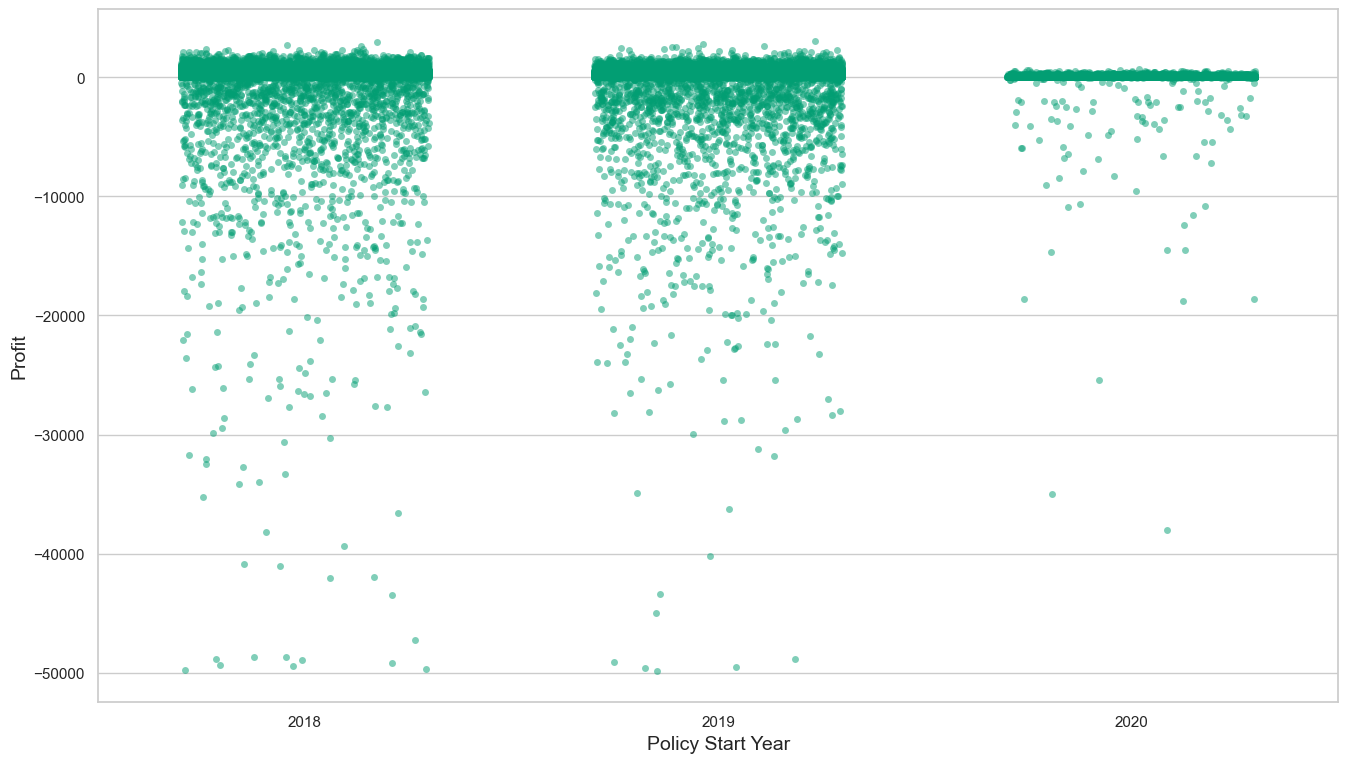

In [16]:
fig = plt.figure(figsize = (16,9))

sns.stripplot(data = df,
            x = "start_year",
            y = "profit",
            jitter = 0.3,
            alpha = 0.5,
            color = sns.color_palette("colorblind")[2])
            
plt.xlabel("Policy Start Year", fontsize = 14)
plt.ylabel("Profit", fontsize = 14)

plt.show()

### FREQUENCY AND SEVERITY

In [17]:
# Calculating Claims Frequency
claims_frequency = df["claim_count"].sum() / df["exposure"].sum()

print(f"The total number of claims is {df["claim_count"].sum()}")
print(f"The total number of vehicles vehicle-years at risk is {round(df['exposure'].sum(), 2)}")
print(f"The claims frequency is {round(claims_frequency, 2)} claims per year")

frequency = (
    df.groupby("start_year")[["exposure", "claim_count"]]
        .sum()
)
frequency["frequency"] = round(frequency["claim_count"] / frequency["exposure"], 6)

#frequency.to_csv(Path.cwd () / "Reports" / "frequency.csv", index = False)

The total number of claims is 7934
The total number of vehicles vehicle-years at risk is 71959.47
The claims frequency is 0.11 claims per year


In [18]:
severity = (
    df.groupby("start_year")
      .agg(
          total_incurred=("final_incurred", "sum"),
          total_claims=("claim_count", "sum")
      )
)

severity["severity"] = (
    severity["total_incurred"]
    / severity["total_claims"]
)
severity

,total_incurred,total_claims,severity
start_year,,,
2018,9942032.88,4065,2445.764546
2019,9127966.39,3700,2467.017943
2020,537094.88,169,3178.076213


In [19]:
freq_sev = (
    pd.merge(frequency, severity, left_on=frequency.index,right_on=severity.index)
        .drop(columns = "total_claims")
        .rename(columns = {"key_0":"start_year", "claim_count":"claims"})
        .iloc[:, [0, 2, 1, 4, 3, 5]]
)

freq_sev["pure_premium"] = freq_sev["frequency"] * freq_sev["severity"]

freq_sev

,start_year,claims,exposure,total_incurred,frequency,severity,pure_premium
0,2018,4065,34379.416438,9942032.88,0.118239,2445.764546,289.184754
1,2019,3700,35402.257134,9127966.39,0.104513,2467.017943,257.835446
2,2020,169,2177.800742,537094.88,0.077601,3178.076213,246.621892


In [20]:
freq_sev2 = freq_sev.merge(
    right = df.groupby("start_year").net_written_premium.mean().reset_index(),
    on = "start_year")

freq_sev2["added_on"] = freq_sev2["net_written_premium"] - freq_sev2["pure_premium"]

freq_sev2.columns = [
    "Start Year", "Claims", "Years at Risk", "Total Incurred", "Frequency", "Severity", "Pure Premium",
    "Net Written Premium", "Added On"
]

for col in freq_sev2.select_dtypes(include="number").columns:
    freq_sev2[col] = round(freq_sev2[col], 2)


freq_sev2
#freq_sev2.to_csv(Path.cwd() / "Reports" / "frequency_severity.csv", index = False)

,Start Year,Claims,Years at Risk,Total Incurred,Frequency,Severity,Pure Premium,Net Written Premium,Added On
0,2018,4065,34379.42,9942032.88,0.12,2445.76,289.18,380.11,90.92
1,2019,3700,35402.26,9127966.39,0.10,2467.02,257.84,355.31,97.47
2,2020,169,2177.80,537094.88,0.08,3178.08,246.62,350.22,103.60


In [48]:
#Frequency of each claim type
freq_sev_type = pd.DataFrame({
    "frequency": [
        df["bi_count"].sum() / df["exposure"].sum(),
        df["ad_count"].sum() / df["exposure"].sum(),
        df["pd_count"].sum() / df["exposure"].sum(),
        df["th_count"].sum() / df["exposure"].sum(),
        df["ws_count"].sum() / df["exposure"].sum()
    ],
    "severity": [
        df["bi_incurred"].sum() / df["bi_count"].sum(),
        df["ad_incurred"].sum() / df["ad_count"].sum(),
        df["pd_incurred"].sum() / df["pd_count"].sum(),
        df["th_incurred"].sum() / df["th_count"].sum(),
        df["ws_incurred"].sum() / df["ws_count"].sum()
    ]
}, index=["Bodily Injuries", "Accidental", "Third Party Property", "Fire/Theft", "Windscreen"])

freq_sev_type["pure_premium"] = freq_sev_type["frequency"] * freq_sev_type["severity"]

freq_sev_type = (
    freq_sev_type.sort_values("severity", ascending=False)
    .rename(columns = {
        "frequency":"Frequency",
        "severity":"Severity",
        "pure_premium":"Pure Premium"
    })
)

freq_sev_type["Frequency"] = round(freq_sev_type["Frequency"], 3)
freq_sev_type["Severity"] = round(freq_sev_type["Severity"], 2)
freq_sev_type["Pure Premium"] = round(freq_sev_type["Pure Premium"], 2)

freq_sev_type = (
    freq_sev_type.reset_index()
    .rename(columns = {"index":"Claim Type"})
)

freq_sev_type
freq_sev_type.to_csv(Path.cwd() / "Reports" / "frequency_severity_by_type.csv", index = False)

## Profiling Customer Who Made Claims

### Number of Claims by Policy Year

In [22]:
# Calculating number of claims by start_year and the number of people making claims

yearly_claims = (
    pd.merge(left = df.groupby("start_year").claim_count.sum().reset_index(),
        right = df[df["claim_count"] > 0].groupby("start_year").id.count().reset_index(),
        on = "start_year")
    .rename(columns={"start_year":"Start Year",
                     "claim_count":"Total Claims",
                     "id":"Number of Customers",})
)

yearly_claims

,Start Year,Total Claims,Number of Customers
0,2018,4065,3767
1,2019,3700,3486
2,2020,169,166


### Average Claim Value by Year

In [23]:
# Subsetting customers that made claims
df_claimed = df[df["claim_count"] > 0]

print(f"{df_claimed.shape[0]} customers made a claim")

# Calculating the average cost per claim
df_claimed["mean_claim_value"] = df_claimed["final_incurred"] / df_claimed["claim_count"]

print(f"The average claim value is {round(df_claimed["mean_claim_value"].mean(), 2)}")

df_claimed.groupby("start_year").agg(
    mean_claim = ("mean_claim_value", "mean"),
    median_caim = ("mean_claim_value", "median")
)

7419 customers made a claim
The average claim value is 2470.89


,mean_claim,median_caim
start_year,,
2018,2435.877880,194.0
2019,2479.499081,230.1
2020,3084.603012,632.5


<Figure size 1600x900 with 0 Axes>

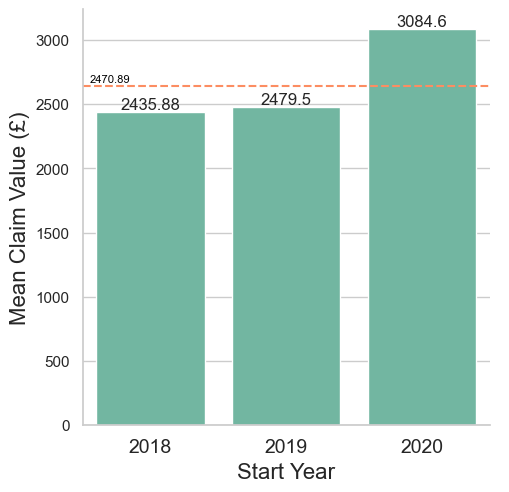

In [24]:
# Calculating the average claim cost each year
mean_claim_by_year = df_claimed.groupby("start_year").mean_claim_value.mean().reset_index()

fig = plt.figure(figsize=(16, 9))

sns.set_theme(style = "whitegrid")

sns.catplot(data = mean_claim_by_year,
            x = "start_year",
            y = "mean_claim_value",
            kind = "bar",
            color = sns.color_palette("Set2")[0])

plt.xlabel("Start Year", fontsize=16)
plt.ylabel("Mean Claim Value (£)", fontsize=16)
plt.xticks(fontsize=14)
plt.axhline(y=round(df_claimed["final_incurred"].mean(), 2),
            color = sns.color_palette("Set2")[1],
            linestyle="--")

plt.text(x=-0.45,
         y=round(df_claimed["mean_claim_value"].mean(), 2) + 200,
         s=str(round(df_claimed["mean_claim_value"].mean(), 2)),
         fontsize=8,
         color="black")

for i, v in enumerate(mean_claim_by_year["mean_claim_value"]):
    plt.text(i, v, str(round(v, 2)), ha = "center", va = "bottom")

plt.show()

In [25]:
kruskal(
    df_claimed.loc[df["start_year"] == 2018, "mean_claim_value"],
    df_claimed.loc[df["start_year"] == 2019, "mean_claim_value"],
    df_claimed.loc[df["start_year"] == 2020, "mean_claim_value"]
)

KruskalResult(statistic=np.float64(8.021622462314419), pvalue=np.float64(0.01811869082674319))

In [26]:
posthoc = sp.posthoc_dunn(
    df_claimed,
    val_col="mean_claim_value",
    group_col="start_year",
    p_adjust="holm"
)

print(posthoc)

          2018      2019      2020
2018  1.000000  0.201916  0.021795
2019  0.201916  1.000000  0.042628
2020  0.021795  0.042628  1.000000


### Number of High Claims

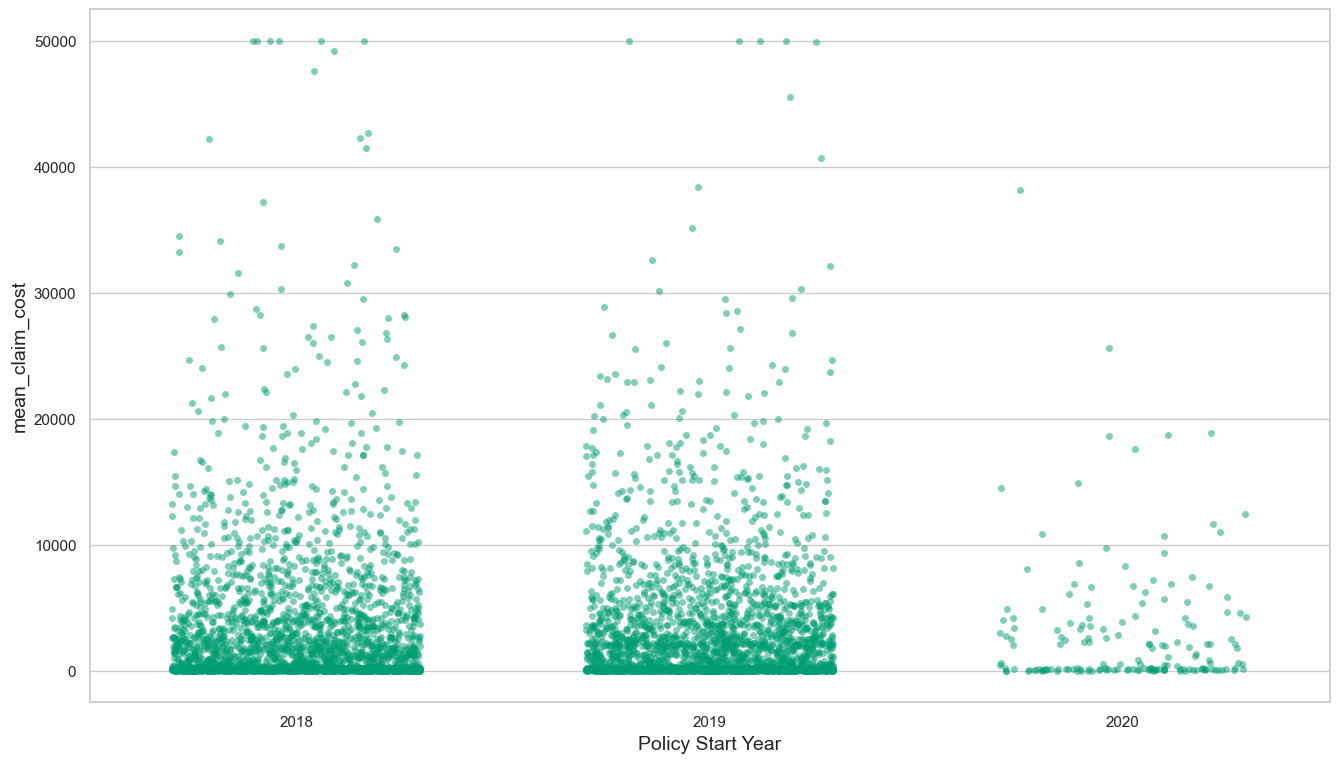

In [27]:
fig = plt.figure(figsize = (16,9))

sns.stripplot(data = df_claimed,
            x = "start_year",
            y = "mean_claim_value",
            jitter = 0.3,
            alpha = 0.5,
            color = sns.color_palette("colorblind")[2])
            
plt.xlabel("Policy Start Year", fontsize = 14)
plt.ylabel("mean_claim_cost", fontsize = 14)

plt.show()

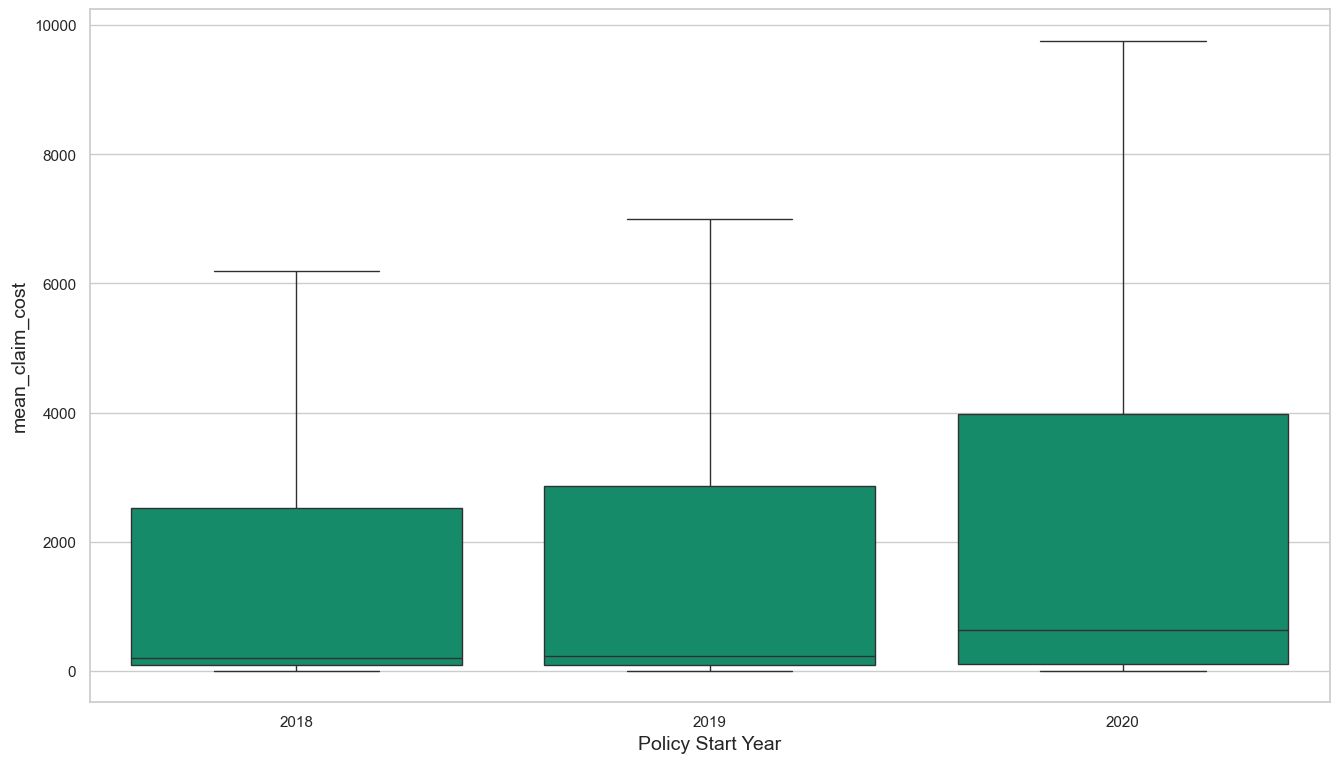

In [28]:
fig = plt.figure(figsize = (16,9))

sns.boxplot(data = df_claimed,
            x = "start_year",
            y = "mean_claim_value",
            color = sns.color_palette("colorblind")[2],
           showfliers = False)
            
plt.xlabel("Policy Start Year", fontsize = 14)
plt.ylabel("mean_claim_cost", fontsize = 14)

plt.show()

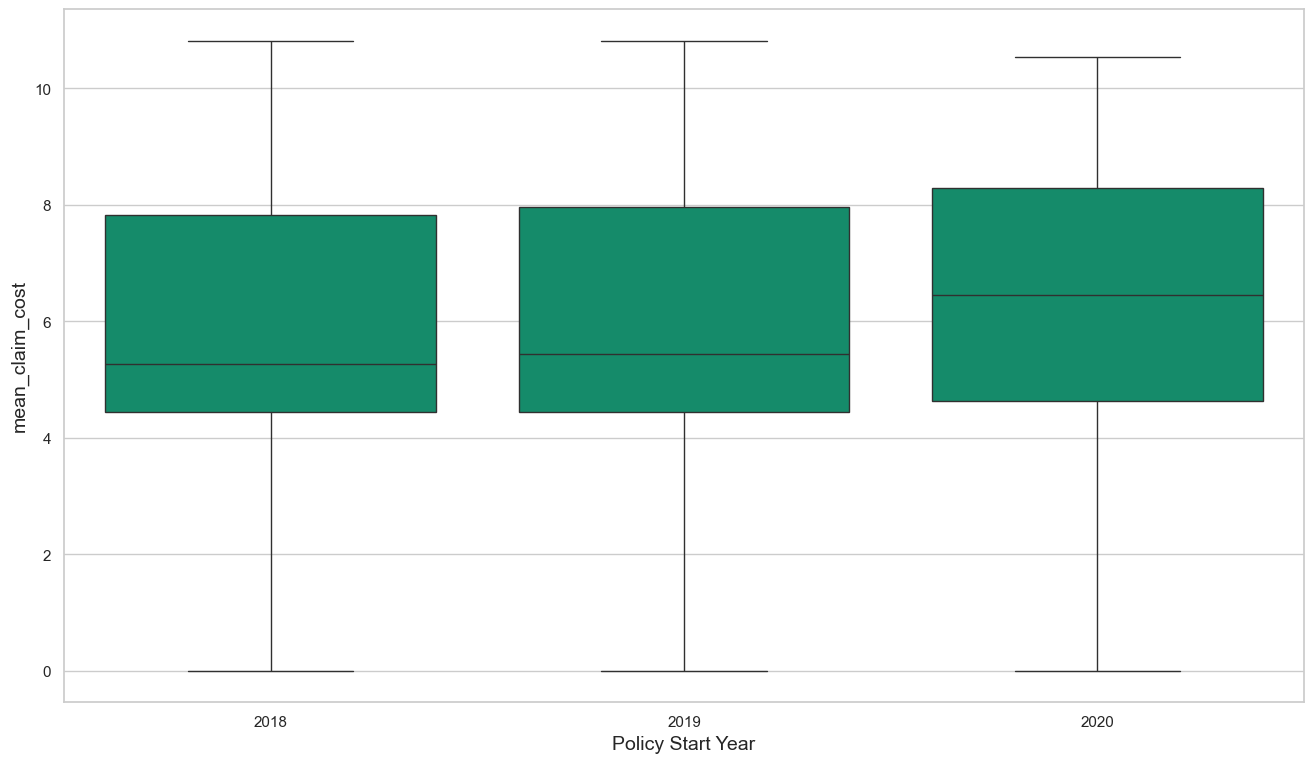

In [29]:
fig = plt.figure(figsize = (16,9))

sns.boxplot(data = df_claimed,
            x = "start_year",
            y = np.log1p(df_claimed["mean_claim_value"]),
            color = sns.color_palette("colorblind")[2])
            
plt.xlabel("Policy Start Year", fontsize = 14)
plt.ylabel("mean_claim_cost", fontsize = 14)

plt.show()

### Type of Claims Made

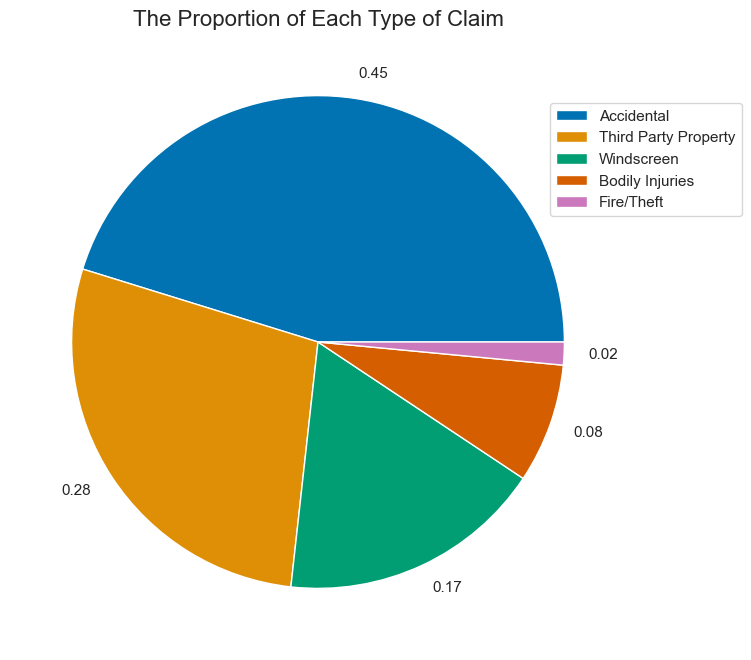

In [30]:
# Distribution of claim type
claims_by_type = (
    df_claimed.loc[:, ["bi_count", "ad_count", "pd_count", "th_count", "ws_count"]].sum()
    .reset_index()
)
claims_by_type.columns = ["Type", "Frequency"]

claims_by_type["Type"] = claims_by_type["Type"].str.replace(
    {
        "ad_count":"Accidental",
        "pd_count":"Third Party Property",
        "ws_count":"Windscreen",
        "bi_count":"Bodily Injuries",
        "th_count": "Fire/Theft"
    }
)

claims_by_type = claims_by_type.sort_values("Frequency", ascending=False)

# Calculating Proportion
claims_by_type["Proportion"] = claims_by_type["Frequency"] / claims_by_type["Frequency"].sum()


fig = plt.figure(figsize = (8, 8))

plt.pie(data = claims_by_type,
        x = "Proportion",
        labels = round(claims_by_type["Proportion"], 2),
        colors = sns.color_palette("colorblind", n_colors = 5))

plt.legend(claims_by_type["Type"], loc='upper right', bbox_to_anchor=(1.2, 0.9))
plt.title("The Proportion of Each Type of Claim", fontsize = 16)

plt.show()

### Investigating No Claims Discounts

In [31]:
ncd_to_reduce = (
    df_claimed[(df_claimed["ncd"] > 0) & (df_claimed["pncd"] == "N")]
    .loc[:, ["id", "ncd", "pncd", "claim_count"]]
    .reset_index(drop=True)
)

ncd_to_reduce.head()

,id,ncd,pncd,claim_count
0,61956,6,N,1
1,35145,3,N,1
2,93633,9,N,1
3,54363,1,N,1
4,59231,2,N,1


In [32]:
offer_pncd = (
    df[(df["claim_count"] == 0) & (df["pncd"] == "N")]
    .loc[:, ["id", "ncd", "pncd", "claim_count"]]
    .reset_index(drop=True)
)

offer_pncd.head()

,id,ncd,pncd,claim_count
0,16042,0,N,0
1,65415,0,N,0
2,89268,8,N,0
3,47359,9,N,0
4,22527,0,N,0


## Investigating Claim Values

In [33]:
# Calculating the average claim cost by gender
mean_claim_by_gender = df_claimed.groupby("gender").mean_claim_value.mean().reset_index()

# Calculating the average claim cost by age
mean_claim_by_age = df_claimed.groupby("d1_age").mean_claim_value.mean().reset_index()

# Calculating the average claim cost by vehicle make
mean_claim_by_make = df_claimed.groupby("vehicle_make").mean_claim_value.mean().reset_index()

# Calculating the average claim cost by vehicle use
mean_claim_by_use = df_claimed.groupby("vehicle_use").mean_claim_value.mean().reset_index()

# Calculating the average claim cost by cover
mean_claim_by_cover = df_claimed.groupby("cover").mean_claim_value.mean().reset_index()

### Vehicle Value

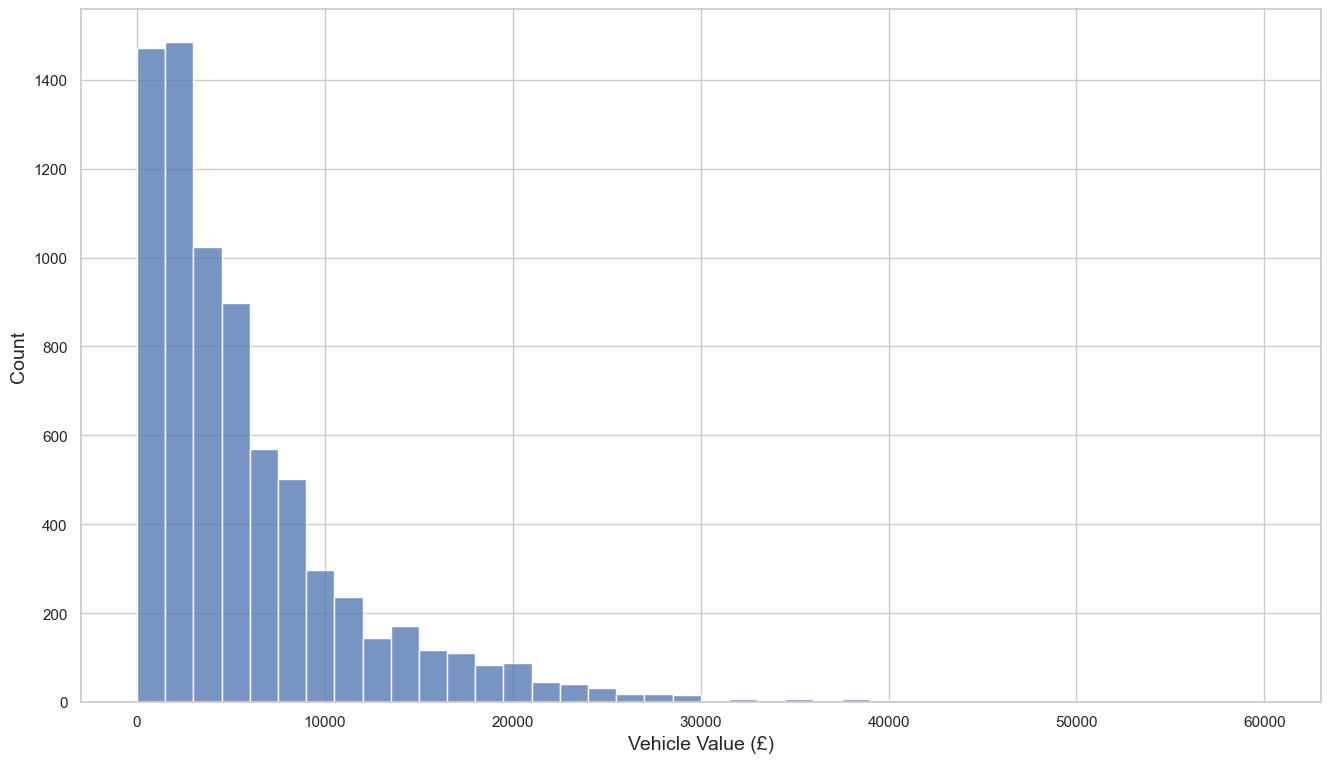

In [34]:
fig = plt.figure(figsize = (16,9))

sns.histplot(data = df_claimed,
            x = "vehicle_value",
            bins = 40)

plt.xlabel("Vehicle Value (£)", fontsize = 14)
plt.ylabel("Count", fontsize = 14)

plt.show()

<Figure size 1600x900 with 0 Axes>

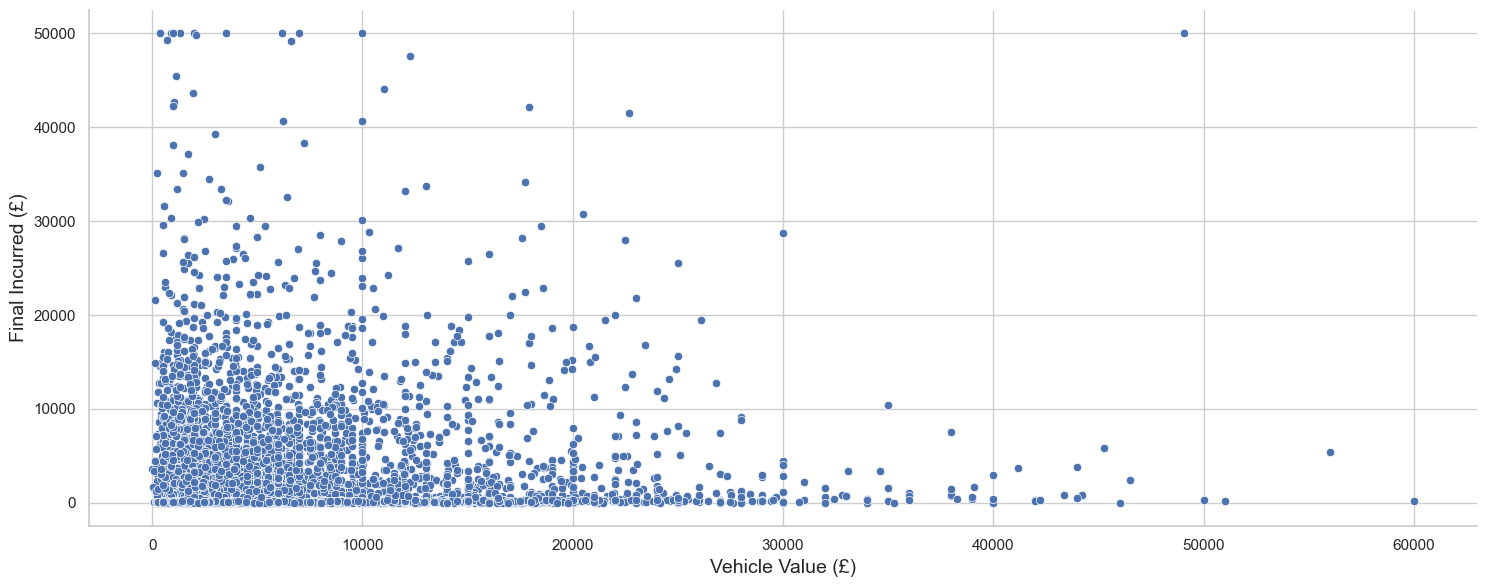

In [35]:
fig = plt.figure(figsize = (16,9))

sns.relplot(data = df_claimed,
           y = "final_incurred",
           x = "vehicle_value",
           kind = "scatter",
           aspect = 2.5,
           height = 6)

plt.xlabel("Vehicle Value (£)", fontsize = 14)
plt.ylabel("Final Incurred (£)", fontsize = 14)

plt.show()

I would have expected the final incurred fees to be greater for more expensive vehicles, not cheaper.

<Figure size 1600x900 with 0 Axes>

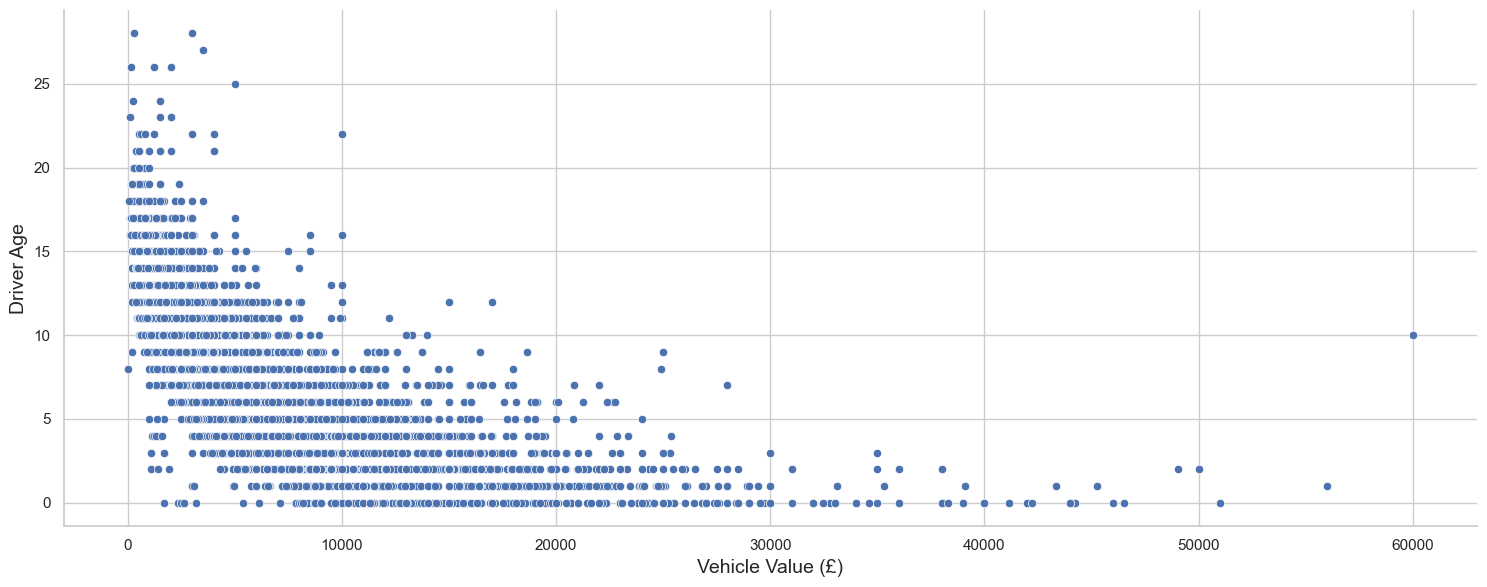

In [36]:
fig = plt.figure(figsize = (16,9))

sns.relplot(data = df_claimed,
           y = "vehicle_age",
           x = "vehicle_value",
           kind = "scatter",
           aspect = 2.5,
           height = 6)

plt.xlabel("Vehicle Value (£)", fontsize = 14)
plt.ylabel("Driver Age", fontsize = 14)

plt.show()

A reason that cheaper vehicles incurr greater fees could be their age, perhaps more severe accidents are happening due to faulty vehicles

<Figure size 1600x900 with 0 Axes>

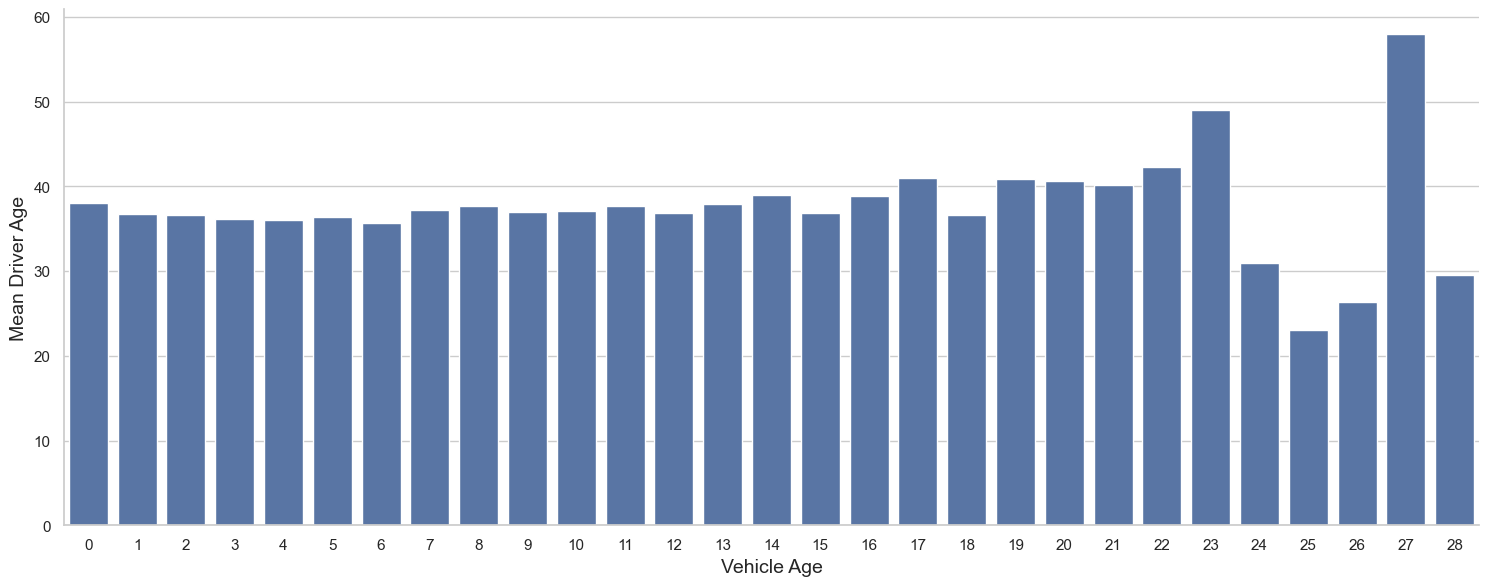

In [37]:
# Finding the mean age of drivers for each vehicle age.
vehicle_driver_age = df_claimed.groupby("vehicle_age").d1_age.mean().reset_index().rename(columns={"d1_age":"mean_d1_age"})

fig = plt.figure(figsize = (16,9))

sns.catplot(data = vehicle_driver_age,
           y = "mean_d1_age",
           x = "vehicle_age",
           kind = "bar",
           aspect = 2.5,
           height = 6)

plt.xlabel("Vehicle Age", fontsize = 14)
plt.ylabel("Mean Driver Age", fontsize = 14)

plt.show()

Young/Old drivers aren't really purchasing older cards compared to newer cards.

### Vehicle Use

<Figure size 1600x900 with 0 Axes>

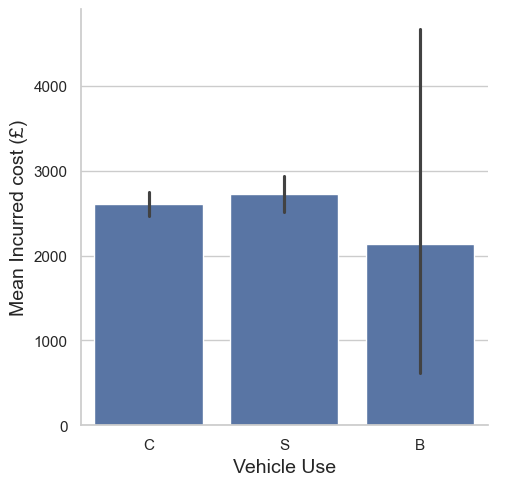

In [38]:
#Mean incurred cost by Vehicle use
by_vehicle_use = (
    df_claimed.groupby("vehicle_use").final_incurred.mean()
        .reset_index()
        .rename(columns={"final_incurred":"mean_incurred"})
)

fig = plt.figure(figsize = (16,9))

sns.catplot(data = df_claimed,
           y = "final_incurred",
           x = "vehicle_use",
           kind = "bar",
           errorbar=('ci', 95))

plt.xlabel("Vehicle Use", fontsize = 14)
plt.ylabel("Mean Incurred cost (£)", fontsize = 14)
#plt.xticks(ticks = [0, 1, 2],
  #         labels = ["Business", "Commuting and Social", "Social, Domestic and Pleasure"],
   #       rotation = 45)

plt.show()

### Driver Age

<Figure size 1600x900 with 0 Axes>

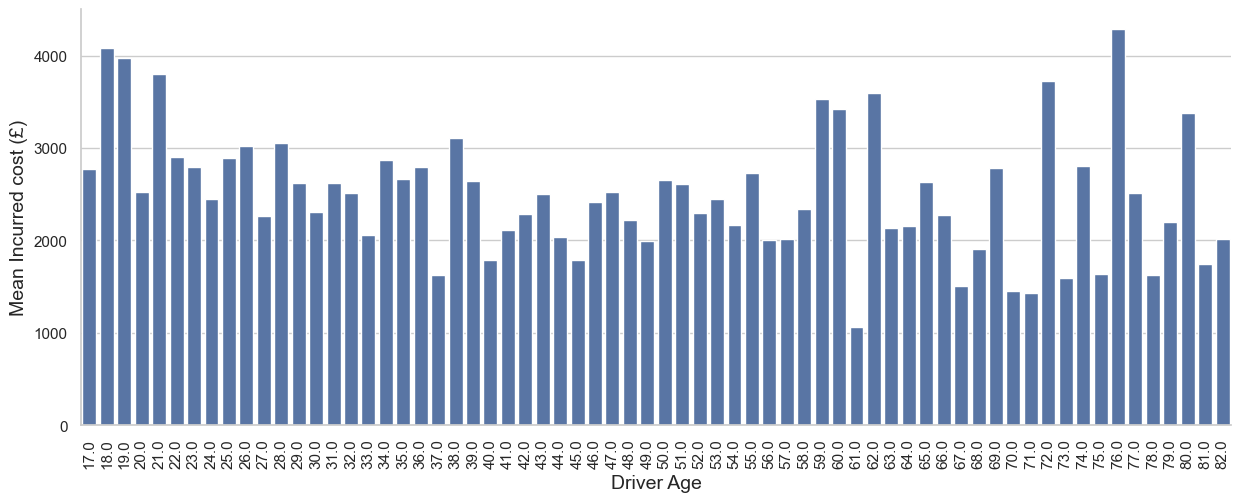

In [39]:
fig = plt.figure(figsize = (16,9))

sns.catplot(data = df_claimed,
           y = "final_incurred",
           x = "d1_age",
           kind = "bar",
           aspect = 2.5,
           errorbar=None)

plt.xlabel("Driver Age", fontsize = 14)
plt.ylabel("Mean Incurred cost (£)", fontsize = 14)
plt.xticks(rotation = 90)

plt.show()

### Claim Type

In [40]:
# Aggregating by Claim Type

by_claim_type = (
    df_claimed.loc[:, ["bi_incurred", "ad_incurred", "pd_incurred", "th_incurred", "ws_incurred"]]
        .sum()
        .reset_index()
        .rename(columns={"index":"Type", 0:"total_incurred"})
    
)
by_claim_type["proportion"] = round((by_claim_type["total_incurred"] / by_claim_type["total_incurred"].sum()), 2)

by_claim_type = by_claim_type.sort_values("total_incurred", ascending = False)

by_claim_type["Type"] = by_claim_type["Type"].str.replace(
    {
        "ad_incurred":"Accidental",
        "pd_incurred":"Third Party Property",
        "ws_incurred":"Windscreen",
        "bi_incurred":"Bodily Injuries",
        "th_incurred": "Fire/Theft"
    }
)

by_claim_type = (
    by_claim_type.set_index('Type')
       .reindex(claims_by_type['Type'])
       .reset_index()
)

by_claim_type

,Type,total_incurred,proportion
0,Accidental,4969271.36,0.23
1,Third Party Property,8023300.89,0.38
2,Windscreen,200168.46,0.01
3,Bodily Injuries,7339314.17,0.35
4,Fire/Theft,619012.96,0.03


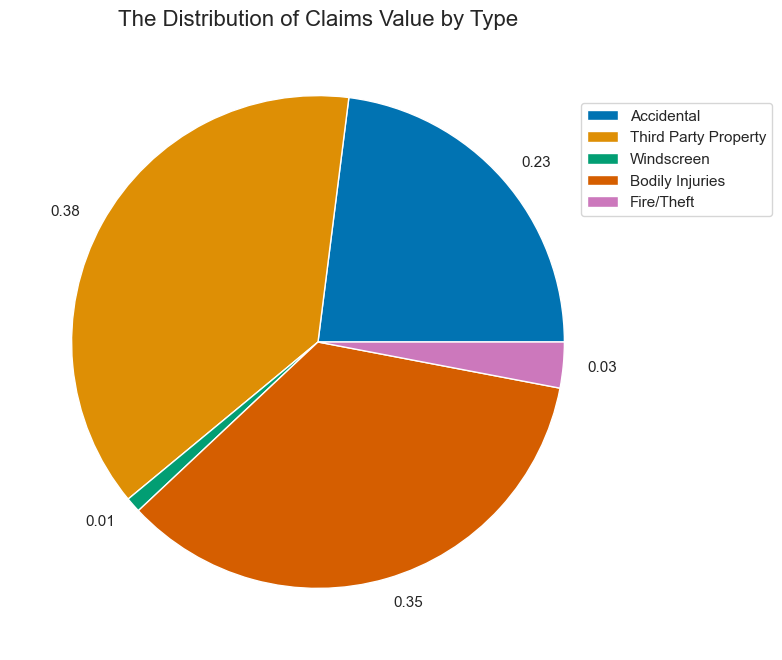

In [41]:
fig = plt.figure(figsize = (8, 8))

plt.pie(data = by_claim_type,
        x = "proportion",
        labels = round(by_claim_type["proportion"], 2),
        colors = sns.color_palette("colorblind", n_colors = 5))

plt.legend(claims_by_type["Type"], loc='upper right', bbox_to_anchor=(1.25, 0.9))
plt.title("The Distribution of Claims Value by Type", fontsize = 16)

plt.show()

### Gender

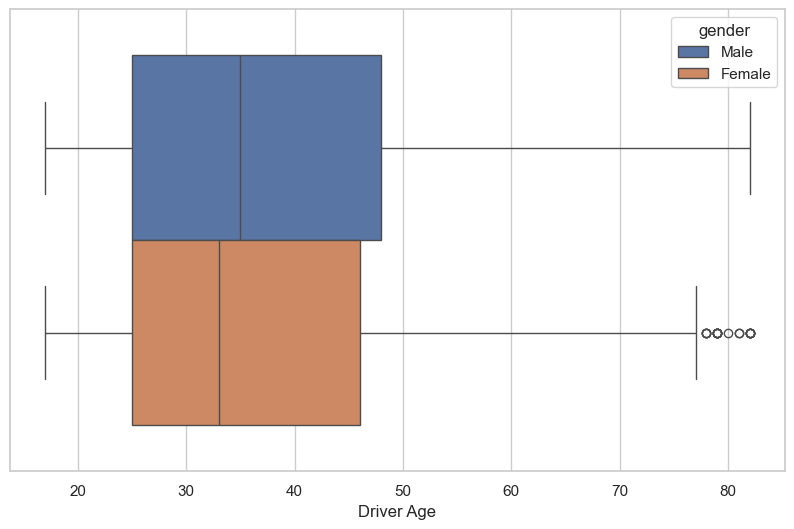

In [42]:
# Plotting the age distribution of each gender
fig = plt.figure(figsize = (10,6))

sns.boxplot(data = df_claimed,
            x = "d1_age",
            hue = "gender",
            hue_order = ["Male", "Female"])

plt.xlabel("Driver Age")

plt.show()

In [43]:
by_gender = (
    df_claimed.groupby("gender").final_incurred.sum()
        .reset_index()
        .rename(columns = {"index":"gender", "final_incurred":"total_incurred"})
)

by_gender2 = (
    df_claimed.groupby("gender").final_incurred.mean()
        .reset_index()
        .rename(columns = {"index":"gender", "final_incurred":"mean_incurred"})
)

by_gender2

,gender,mean_incurred
0,Female,2394.891943
1,Male,2864.843610


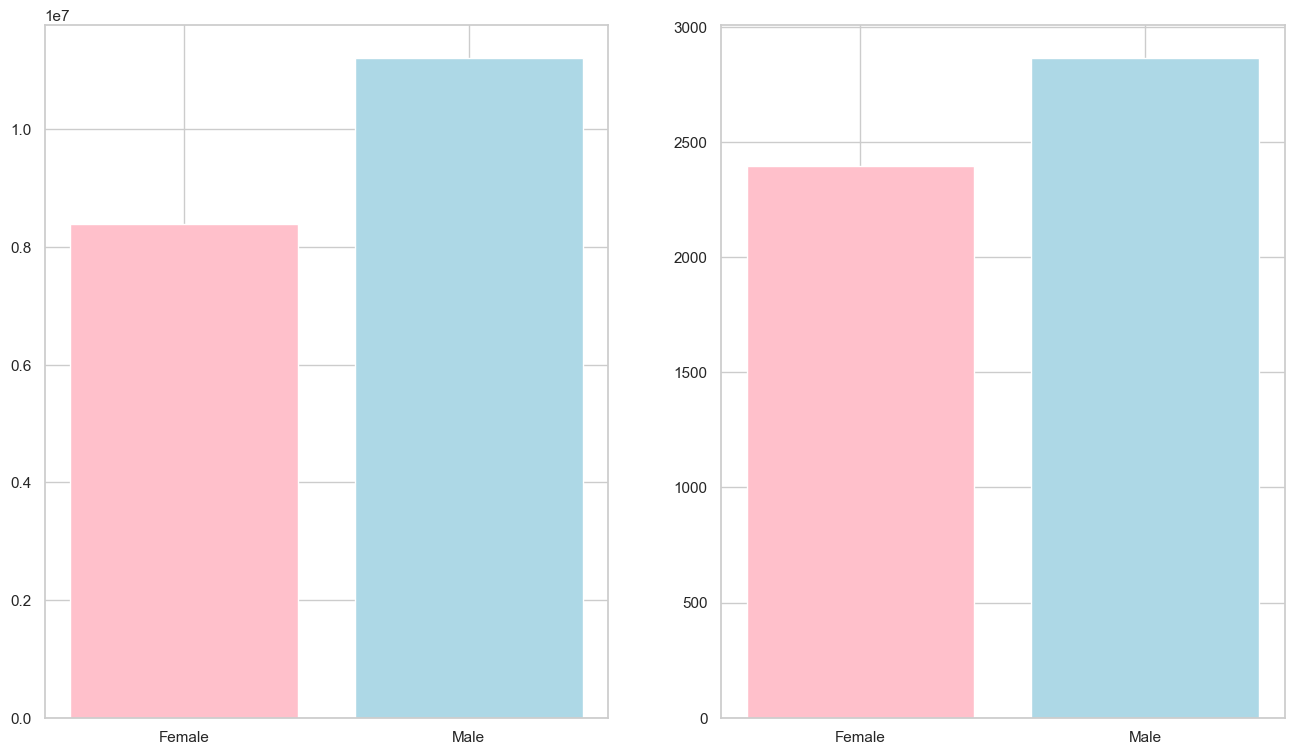

In [44]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (16,9))

ax1.bar(data = by_gender,
    x = "gender",
    height = "total_incurred",
       color = ["Pink", "lightblue"])

ax2.bar(data = by_gender2,
    x = "gender",
    height = "mean_incurred",
       color = ["Pink", "lightblue"])

plt.show()

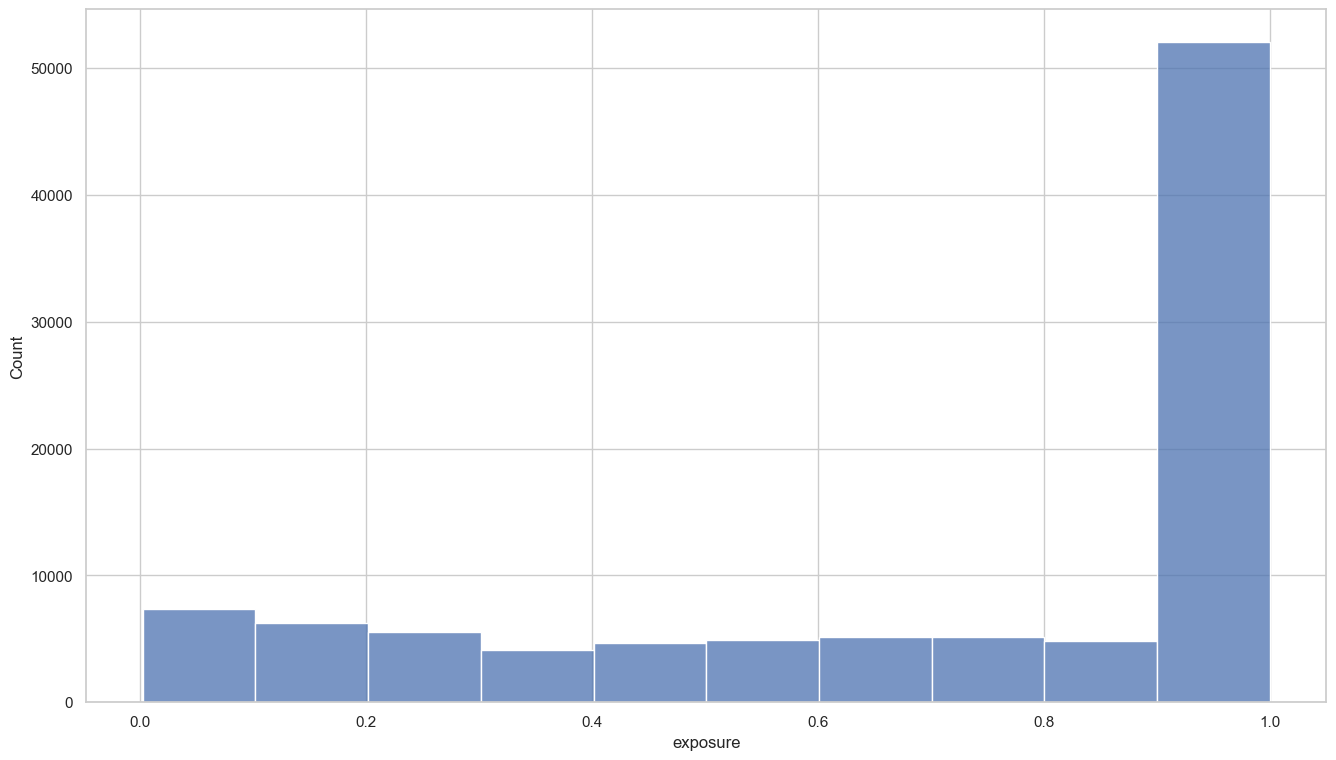

In [45]:
# Exposure distribution

fig = plt.figure(figsize = (16,9))

sns.histplot(data = df,
            x = "exposure",
             bins = 10)

plt.show()

## Profiling Customers Who Did Not Make Claims

In [46]:
# Identifying "safest" demographic.
df_no_claim = df[df["claim_count"] == 0]

df_no_claim.groupby("gender").id.count()

gender
Female     42515
Male       50064
Unknown        2
Name: id, dtype: int64